In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os
os.listdir('/content/drive/MyDrive')

['Colab Notebooks', 'Machine_Learning_lab', 'USA_Housing.csv']

In [3]:
import os
os.listdir("/content/drive/MyDrive/Machine_Learning_lab")

['winequality.names',
 'winequality-red.csv',
 'winequality-white.csv',
 'yahoo_data.xlsx']

In [4]:
!pip install yfinance

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import yfinance as yf

from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

In [6]:
stock_symbol = "AAPL"
data = yf.download(stock_symbol, start="2015-01-01", end="2024-01-01")

print("Dataset Loaded Successfully")
data.head()

/tmp/ipython-input-902375187.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(stock_symbol, start="2015-01-01", end="2024-01-01")
[*********************100%***********************]  1 of 1 completed

Dataset Loaded Successfully


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2015-01-02,24.214891,24.682224,23.776352,24.671149,212818400
2015-01-05,23.532721,24.064284,23.346674,23.984549,257142000
2015-01-06,23.534937,23.794073,23.173916,23.596952,263188400
2015-01-07,23.864941,23.964608,23.632381,23.743124,160423600
2015-01-08,24.781898,24.839485,24.075362,24.192751,237458000


In [7]:
stock_symbol = "AAPL"
data = yf.download(stock_symbol, start="2015-01-01", end="2024-01-01")

print("Dataset Loaded Successfully")
data.head()

/tmp/ipython-input-902375187.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(stock_symbol, start="2015-01-01", end="2024-01-01")
[*********************100%***********************]  1 of 1 completed

Dataset Loaded Successfully


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2015-01-02,24.214891,24.682224,23.776352,24.671149,212818400
2015-01-05,23.532721,24.064284,23.346674,23.984549,257142000
2015-01-06,23.534937,23.794073,23.173916,23.596952,263188400
2015-01-07,23.864941,23.964608,23.632381,23.743124,160423600
2015-01-08,24.781898,24.839485,24.075362,24.192751,237458000


In [8]:
close_price = data[['Close']]
close_price.dropna(inplace=True)

/tmp/ipython-input-4282311759.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  close_price.dropna(inplace=True)


In [9]:
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_close = scaler.fit_transform(close_price)

In [10]:
def create_sliding_window(data, window_size=5):
    X, y = [], []
    for i in range(len(data) - window_size):
        X.append(data[i:i + window_size, 0])   # Feature matrix
        y.append(data[i + window_size, 0])     # Target value
    return np.array(X), np.array(y)

window_size = 5
X, y = create_sliding_window(scaled_close, window_size)

print("Feature Matrix Shape (X):", X.shape)
print("Target Vector Shape (y):", y.shape)

Feature Matrix Shape (X): (2259, 5)
Target Vector Shape (y): (2259,)


In [11]:
train_size = int(len(X) * 0.8)

X_train = X[:train_size]
y_train = y[:train_size]

X_test = X[train_size:]
y_test = y[train_size:]

print("Training Samples:", len(X_train))
print("Testing Samples:", len(X_test))


Training Samples: 1807
Testing Samples: 452


In [12]:
model = LinearRegression()

predictions = []
actuals = []

history_X = list(X_train)
history_y = list(y_train)

for i in range(len(X_test)):
    # Train on past data
    model.fit(np.array(history_X), np.array(history_y))

    # Predict next step
    y_pred = model.predict(X_test[i].reshape(1, -1))
    predictions.append(y_pred[0])
    actuals.append(y_test[i])

    # Move forward (walk-forward)
    history_X.append(X_test[i])
    history_y.append(y_test[i])


In [13]:
predictions = scaler.inverse_transform(
    np.array(predictions).reshape(-1, 1)
)

actuals = scaler.inverse_transform(
    np.array(actuals).reshape(-1, 1)
)


In [14]:
mse = mean_squared_error(actuals, predictions)
rmse = np.sqrt(mse)
mae = mean_absolute_error(actuals, predictions)

print("Mean Squared Error (MSE):", mse)
print("Root Mean Squared Error (RMSE):", rmse)
print("Mean Absolute Error (MAE):", mae)

Mean Squared Error (MSE): 7.7458338868199625
Root Mean Squared Error (RMSE): 2.7831338248133095
Mean Absolute Error (MAE): 2.0989895196432924


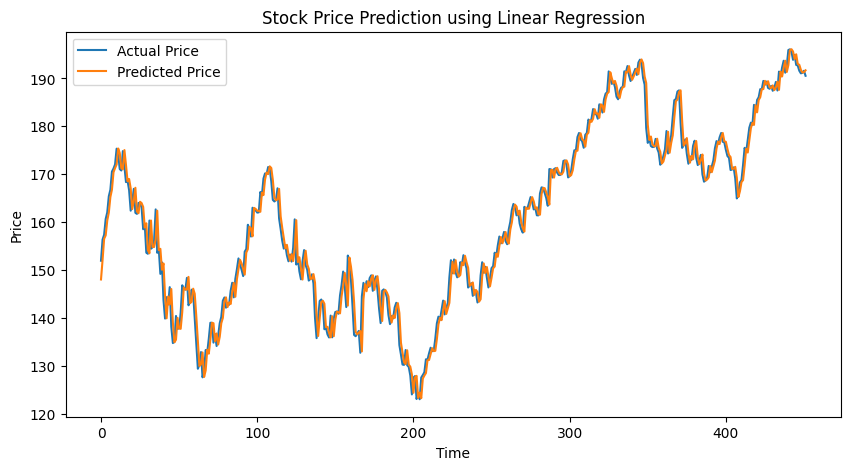

In [15]:
plt.figure(figsize=(10,5))
plt.plot(actuals, label='Actual Price')
plt.plot(predictions, label='Predicted Price')
plt.title("Stock Price Prediction using Linear Regression")
plt.xlabel("Time")
plt.ylabel("Price")
plt.legend()
plt.show()

In [16]:
last_window = scaled_close[-window_size:]
last_window = last_window.reshape(1, -1)

next_day_price = model.predict(last_window)
next_day_price = scaler.inverse_transform(
    next_day_price.reshape(-1, 1)
)

print("Predicted Next Day Stock Price:", next_day_price[0][0])

Predicted Next Day Stock Price: 190.6876922780405
